In [2]:
import os
import importlib
import sys

# for math operations
import numpy as np
import scipy

# for plotting
from IPython.display import HTML
import matplotlib.pyplot as plt
import matplotlib.animation as anim
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# for accelerated computing
import jax
import jax.numpy as jnp
import torch

# Python reachability toolbox
import hj_reachability as hj

# QP tools
import osqp
from scipy import sparse

import matplotlib.animation as animation
import matplotlib.patches as patches

In [3]:
# Load dynamics
import dubins_model
importlib.reload(dubins_model)
from dubins_model import Dubins3D

dubins = Dubins3D()

In [4]:
# Load learned value function

import latent_dubin_ca_value
importlib.reload(latent_dubin_ca_value)
from latent_dubin_ca_value import latent_dubin_ca_value
value_func = latent_dubin_ca_value()

/home/arun/PhD_Five/EAIS/.conda/lib/python3.11/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Encoder CNN shapes: {'image': (128, 128, 3)}
Encoder MLP shapes: {'obs_state': (2,)}
Decoder CNN shapes: {'image': (128, 128, 3)}
Decoder MLP shapes: {'obs_state': (2,)}
decoder


/home/arun/PhD_Five/EAIS/latent-affine-safety/eais_hw2/dreamerv3-torch/tools.py:904: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self._scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


Optimizer model_opt has 27133189 variables.
DDPG under the Avoid annealed Bellman equation with no Disturbance has been loaded!


100%|##########|  2.8000/2.799999952316284 [00:00<00:00, 14.41sim_s/s]


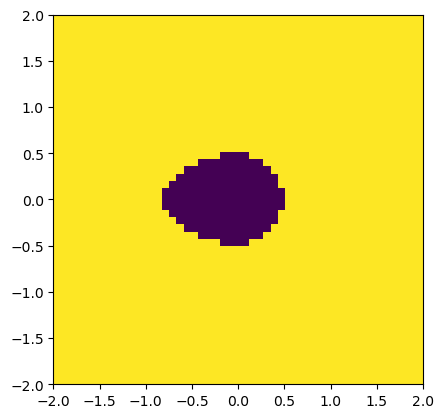

In [5]:
sys.path.append('./value_functions')
import hj_value_function
importlib.reload(hj_value_function)
from hj_value_function import HJValueFunction

ground_truth_value_func = HJValueFunction(dubins)

# Define failure set
obstacle1 = jnp.linalg.norm(np.array([0.0, 0.0]) - ground_truth_value_func.grid.states[..., :2], axis=-1) - value_func.param['radius']
failure_lx = obstacle1

ground_truth_value_func.compute_V(failure_lx)

plt.imshow(ground_truth_value_func.val_grid[:, :, 0].T>0, origin='lower', extent=[-2, 2, -2, 2])

[0.87541044]
[0.67176473]
[0.44934607]
[0.43487865]
[0.43067]
[0.39523014]
[0.33306018]
[0.29579973]
[0.17566007]
[0.1160993]
[0.0277192]
[-0.03714895]
[0.05246723]
[0.13388419]
[0.2243672]
[0.3161683]
[0.38091335]
[0.45856947]
[0.4195027]
[0.5225189]
[0.7536152]
[0.811112]
[0.80949014]
[0.7603406]
[0.70716345]
[0.74417365]
[0.7855484]
[0.8125252]
[0.83447903]
[0.81107163]
[0.7859066]
[0.7511693]
[0.7058975]
[0.69044]
[0.675804]
[0.6723826]
[0.66397774]
[0.6643641]
[0.5934749]
[0.55637294]
[0.57734096]
[0.59022397]
[0.5871283]
[0.57491434]
[0.5672576]
[0.55717313]
[0.54612195]
[0.5902996]
[0.616006]


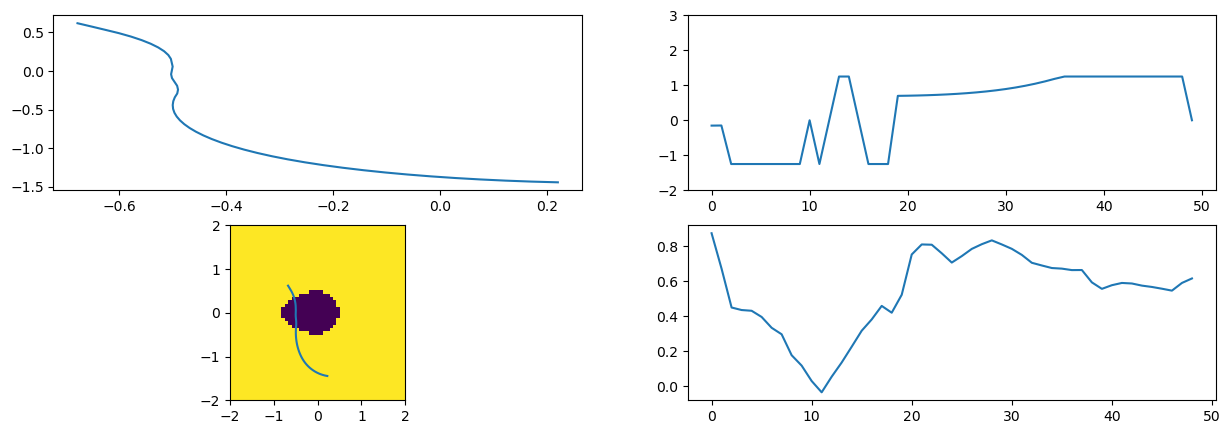

In [16]:
# Simulate with QP
# import safety_policies
# importlib.reload(safety_policies)
# from safety_policies import safety_filter, qp_filter

N = 50
dt = 0.05
actions = torch.zeros(N, 1)
values = torch.zeros(N, 1)
states = torch.zeros(N, 3)
states[0,:] = torch.tensor([-0.6774,  0.6195, -1.0222])
u_max = 1.25

# Define function for gradient
# vgrad = lambda state: get_spatial_grad(value_func.V, state, eps=0.05)

eps = 0.3
dubins.speed = 1.0
goal_state = torch.tensor([0.0, -1.0, 0])
num_samples = 3
value_series = []
for k in range(0, N-1):
    # Nominal policy, steer towards goal
    err = dubins.state_error(goal_state, states[k, :])
    if np.linalg.norm(err[:2]) < 0.1:
        dubins.speed = 0 # Stop when we reach the goal
        actions[k, 0] = 0
    else:
        theta = np.arctan2(err[1], err[0])
        theta_err = dubins.state_error(torch.tensor([0, 0, theta]), states[k, :])[2]
        actions[k, 0] = max(-u_max, min(u_max, theta_err))

    value = value_func.state_to_V(states[k:k+1, :])
    print(value)
    if value <= 0.5:
        # Sample across actions and include nominal policy
        possible_actions = torch.vstack([torch.tensor([u1, u2, u3]) for u1 in np.linspace(-u_max, u_max, num_samples) for u2 in np.linspace(-u_max, u_max, num_samples) for u3 in np.linspace(-u_max, u_max, num_samples)])

        # Propogate to next states
        next_states = states[k:k+1, :].squeeze().repeat(possible_actions.shape[0], 1)
        values = value_func.state_action_to_V(next_states, possible_actions[:, 0:1])
        next_states = dubins.discrete_dynamics(next_states, possible_actions[:, 0:1], dt)
        values = np.minimum(values, value_func.state_action_to_V(next_states, possible_actions[:, 1:2]))
        next_states = dubins.discrete_dynamics(next_states, possible_actions[:, 1:2], dt)
        values = np.minimum(values, value_func.state_action_to_V(next_states, possible_actions[:, 2:3]))

        # Get averages
        # avg_values = np.mean(np.split(values, num_samples))
        actions[k, 0] = possible_actions[np.argmax(values), 0]

        # actions[k, 0] = np.linspace(-u_max, u_max, num_samples)[np.argmax(avg_values)]


    # possible_actions = torch.concat((torch.linspace(-u_max, u_max, num_samples), actions[k, :])).unsqueeze(1)

    # # Forward simulate actions and get values
    # next_states = dubins.discrete_dynamics(states[k:k+1, :].squeeze().repeat(num_samples+1, 1), possible_actions, dt)
    # values = value_func.state_to_V(next_states)

    # # Cut out any possible actions that lead to negative values
    # print(value_func.state_to_V(states[k:k+1, :]), values)
    # eps = 0.5
    # if len(possible_actions[values > eps]) != 0:
    #     possible_actions = possible_actions[values > eps]

    #     # Get distances between remaining actions and nominal
    #     distances = abs(possible_actions.squeeze() - actions[k, 0])

    #     # Apply closest action
    #     actions[k, 0] = possible_actions[np.argmin(distances)]
    # else:
    #     # Just apply largest
    #     actions[k, 0] = possible_actions[np.argmin(distances)]
    # # print(distances)

    # # Get values
    # # print(value_func.state_to_V(states[k:k+1, :]))

    # # value = value_func.state_to_V(states[k:k+1, :])
    # # if value < 0.8:
    # #     possible_actions = torch.concat((torch.linspace(-u_max, u_max, num_samples), actions[k, :])).unsqueeze(1)
    # #     next_states = dubins.discrete_dynamics(states[k:k+1, :].squeeze().repeat(num_samples+1, 1), possible_actions, dt)
    # #     values = value_func.state_to_V(next_states)
    # #     actions[k, 0] = possible_actions[np.argmax(values)]
    # # # print(actions[k, :])
    # # print(value)
    value_series.append(value)
    # print(actions[k, 0])
    # print(values)
    # print("max", np.max(values))
    # if value < eps:


    #     actions[k, 0] = torch.tensor(act)
    # print(value)

    # vfunc = value_func.state_to_V
    # state = states[k:k+1, :]
    # next_state = dubins.discrete_rk4(state, actions[k:k+1, :], dt)
    # safety_V = vfunc(next_state)
    # print(safety_V)
    # if safety_V <= eps:
    #     safety_V = vfunc(state)
    #     print(safety_V)
    #     possible_actions = torch.concat((torch.linspace(-u_max, u_max, num_samples), actions[k, :])).unsqueeze(1)
    #     next_states = dubins.discrete_rk4(state.squeeze().repeat(num_samples+1, 1), possible_actions, dt)

    #     values = vfunc(next_states)
    #     distances = abs(possible_actions.squeeze() - actions[k, 0])
    #     # print(distances)
    #     print(values)
    #     if len(distances[values > safety_V].squeeze()) > 0:
    #         best_action = torch.argmax(distances[values > safety_V].squeeze())
    #         action_to_take = possible_actions[values > safety_V][best_action]
    #         next_state = next_states[values > safety_V][best_action]
    #     # print(action_to_take)
    #     # print(distances[values > eps])
    #     # print(torch.argmax(distances[values > eps]))
    #         actions[k, 0] = action_to_take
    #         print(action_to_take)
    #         print(next_state)
    #     else:
    #         break

    # Filter the policy using a QP
    # actions[k, 0], status = qp_filter(actions[k, 0], value_func.V, vgrad, states[k:k+1,:], u_max, 0.03, dubins, dt)

    # if status != 'solved': # Fall back to safety filter
    #     print("infeasible", k)
    #     actions[k, 0] = safety_filter(actions[k, 0], value_func.V, vgrad, states[k, :], u_max, eps)
    
    # actions[k, 0] = safety_filter(actions[k, 0], value_func.V, vgrad, states[k, :], u_max, eps)
    
    states[k +1:k+2, :] = dubins.discrete_dynamics(states[k:k+1, :], actions[k:k+1, :], dt)
    # print(states[k + 1, :])

plt.figure(figsize=(15,5))
plt.subplot(2, 2, 1)
plt.plot(states[:, 0], states[:, 1])
plt.subplot(2, 2, 2)
plt.plot(actions)
plt.ylim(-2, 3)
plt.subplot(2, 2, 3)
plt.imshow(ground_truth_value_func.val_grid[:, :, 0].T>0, origin='lower', extent=[-2, 2, -2, 2])
plt.plot(states[:, 0], states[:, 1])
plt.subplot(2, 2, 4)
plt.plot(value_series)

In [17]:
states

tensor([[-0.6774,  0.6195, -1.0222],
        [-0.6513,  0.5768, -1.0298],
        [-0.6256,  0.5340, -1.0373],
        [-0.6001,  0.4909, -1.0998],
        [-0.5775,  0.4464, -1.1623],
        [-0.5576,  0.4005, -1.2248],
        [-0.5406,  0.3534, -1.2873],
        [-0.5267,  0.3054, -1.3498],
        [-0.5157,  0.2567, -1.4123],
        [-0.5078,  0.2073, -1.4748],
        [-0.5030,  0.1575, -1.5373],
        [-0.5013,  0.1075, -1.5373],
        [-0.4997,  0.0576, -1.5998],
        [-0.5011,  0.0076, -1.5998],
        [-0.5026, -0.0424, -1.5373],
        [-0.5009, -0.0924, -1.4748],
        [-0.4961, -0.1421, -1.4748],
        [-0.4913, -0.1919, -1.5373],
        [-0.4896, -0.2419, -1.5998],
        [-0.4911, -0.2918, -1.6623],
        [-0.4956, -0.3416, -1.6274],
        [-0.4985, -0.3916, -1.5923],
        [-0.4995, -0.4415, -1.5569],
        [-0.4988, -0.4915, -1.5211],
        [-0.4964, -0.5415, -1.4848],
        [-0.4921, -0.5913, -1.4479],
        [-0.4859, -0.6409, -1.4101],
 

In [ ]:
fig, ax = plt.subplots()
img = ax.imshow(grid[0, :, :].T, origin='lower', extent=[-1.1, 1.1, -1.1, 1.1])

circ1 = patches.Circle((0, 0), radius=value_func.param['radius'], facecolor='red', edgecolor='red')
ax.add_patch(circ1)
line, = ax.plot([], [])

def animate(k):
    img.set_array(grid[k, :, :].T) #update the image data.
    line.set_data(states[:k, 0], states[:k, 1])
    return img, line,

ani = animation.FuncAnimation(fig, animate, frames=states.shape[0], interval=200, blit=True) #adjust interval

ani.save('reachability_animation.gif')  # Save as GIF

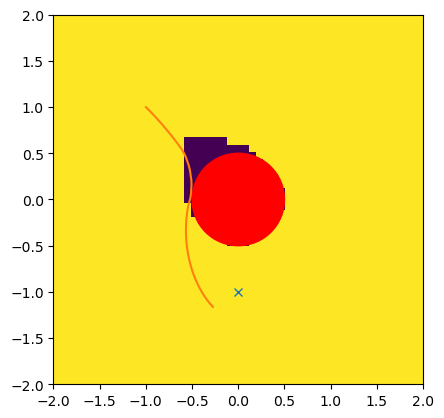

In [10]:
fig, ax = plt.subplots()
img = ax.imshow(ground_truth_value_func.val_grid[:, :, 0].T>0, origin='lower', extent=[-2, 2, -2, 2])
# circ1 = patches.Circle((x_c, y_c), radius=radius, facecolor='red', edgecolor='red')
# ax.add_patch(circ1)
circ1 = patches.Circle((0, 0), radius=value_func.param['radius'], facecolor='red', edgecolor='red')
ax.add_patch(circ1)
ax.plot(goal_state[0], goal_state[1], marker='x')
# obstacle1 = jnp.linalg.norm(np.array([0.0, 0.0]) - value_func.grid.states[..., :2], axis=-1) - radius
# obstacle2 = jnp.linalg.norm(np.array([x_c, y_c]) - value_func.grid.states[..., :2] , axis=-1) - radius
line, = ax.plot([], [])

def animate(k):
    theta_idx = ground_truth_value_func.theta_to_grid(states[k, 2] % (2*np.pi))
    img.set_array(ground_truth_value_func.val_grid[:, :, theta_idx].T>0) #update the image data.
    line.set_data(states[:k, 0], states[:k, 1])
    return img, line,

ani = animation.FuncAnimation(fig, animate, frames=states.shape[0], interval=200, blit=True) #adjust interval

ani.save('reachability_animation.gif')  # Save as GIF

In [ ]:
N = 51

states = torch.vstack([torch.tensor([x, y, 0]) for x in np.linspace(-1, 1, N) for y in np.linspace(-1, 1, N)])
indices = [(x, y) for x in range(N) for y in range(N)]
Vs = value_func.state_to_V(states)


In [8]:
N = 51
angles = torch.tensor([-0.9286, -0.9911, -1.0536, -1.1161, -1.1786, -1.2411, -1.3036, -1.3661,
        -1.4286, -1.4911])
grid = np.ndarray((10, N, N))
for k in range(len(angles)):
    print(k)
    states = torch.vstack([torch.tensor([x, y, angles[k]]) for x in np.linspace(-1, 1, N) for y in np.linspace(-1, 1, N)])
    indices = [(x, y) for x in range(N) for y in range(N)]
    Vs = value_func.state_to_V(states)

    for i in range(len(states)):
        grid[k, indices[i][0], indices[i][1]] = Vs[i]


0
1
2
3
4
5


KeyboardInterrupt: 

In [39]:
import latent_dubin_ca_value
importlib.reload(latent_dubin_ca_value)
from latent_dubin_ca_value import latent_dubin_ca_value
value_func = latent_dubin_ca_value()

N = 20
state = torch.tensor([0.7, 0.0, 0]).repeat(N, 1)
u_max = 1.25
actions = torch.vstack([torch.tensor([u1]) for u1 in np.linspace(-u_max, u_max, N)])
next_states = dubins.discrete_dynamics(state, actions, 0.05)
print(actions)
print(value_func.state_to_V(state))
V1 = value_func.state_to_V(next_states)
V2 = value_func.state_action_to_V(state, actions)
print(V1)
print(V2)

/home/arun/PhD_Five/EAIS/.conda/lib/python3.11/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Encoder CNN shapes: {'image': (128, 128, 3)}
Encoder MLP shapes: {'obs_state': (2,)}
Decoder CNN shapes: {'image': (128, 128, 3)}
Decoder MLP shapes: {'obs_state': (2,)}
decoder
Optimizer model_opt has 27133189 variables.


/home/arun/PhD_Five/EAIS/latent-affine-safety/eais_hw2/dreamerv3-torch/tools.py:904: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self._scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


DDPG under the Avoid annealed Bellman equation with no Disturbance has been loaded!
tensor([[-1.2500],
        [-1.1184],
        [-0.9868],
        [-0.8553],
        [-0.7237],
        [-0.5921],
        [-0.4605],
        [-0.3289],
        [-0.1974],
        [-0.0658],
        [ 0.0658],
        [ 0.1974],
        [ 0.3289],
        [ 0.4605],
        [ 0.5921],
        [ 0.7237],
        [ 0.8553],
        [ 0.9868],
        [ 1.1184],
        [ 1.2500]], dtype=torch.float64)


/home/arun/PhD_Five/EAIS/latent-affine-safety/latent_dubin_ca_value.py:99: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  s0 = torch.tensor(s0, dtype=torch.float32)


[0.90509313 0.90509313 0.90509313 0.90509313 0.90509313 0.90509313
 0.90509313 0.90509313 0.90509313 0.90509313 0.90509313 0.90509313
 0.90509313 0.90509313 0.90509313 0.90509313 0.90509313 0.90509313
 0.90509313 0.90509313]
[0.9034597  0.90271455 0.9020048  0.9015198  0.901187   0.9009412
 0.90061986 0.9002772  0.899921   0.89962715 0.8992833  0.8989147
 0.8985234  0.8980893  0.89768857 0.8972658  0.89690834 0.8965325
 0.8962043  0.89585   ]
[0.8987653  0.8915069  0.89773357 0.8986532  0.88846016 0.8969554
 0.9012266  0.8973682  0.8926278  0.8905245  0.8977999  0.89546186
 0.8921471  0.896104   0.89709616 0.89270526 0.89276105 0.8952829
 0.89578974 0.9004847 ]
